<a href="https://colab.research.google.com/github/KULDEEPSONI-source/DEEPLEARNING/blob/main/Image_Augmentation_SKLEARN_(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import random
from skimage import exposure
from skimage.util import random_noise
from skimage import transform
from cv2 import resize

I'll break down every single import in this code for a complete beginner, explaining what each library does, why you'd use it, and how they all fit together in image processing and deep learning.

---

## The Big Picture

These imports are **image preprocessing and augmentation tools**. Think of them like a photo editing toolkit that you'll use to prepare images before feeding them to a neural network (like the Keras ANN you built earlier).

**Why preprocess images?**
- Neural networks need consistent input sizes
- More training data = better model (augmentation creates "new" images from existing ones)
- Normalized, balanced images help the network learn faster

---

## Import 1: `from skimage import exposure`

```python
from skimage import exposure
```

| What It Is | Explanation |
|------------|-------------|
| **skimage** | Short for **scikit-image** — a Python library for image processing (like Photoshop, but with code) |
| **exposure** | A sub-module that controls **brightness, contrast, and pixel intensity** |

**What `exposure` does:**
- Adjusts how "bright" or "dark" an image is
- Fixes images that are too dark, too bright, or low-contrast
- Makes sure the neural network sees clear details, not just dark blobs

**Analogy:** The "Brightness/Contrast" slider in your phone's photo editor.

**Common functions you can use:**

```python
from skimage import exposure

# 1. Histogram Equalization — spread out dark/light pixels evenly
image_better = exposure.equalize_hist(image)

# 2. Adaptive Equalization — fixes uneven lighting (bright sky, dark ground)
image_adaptive = exposure.equalize_adapthist(image)

# 3. Rescale Intensity — force pixels into a specific range
image_stretched = exposure.rescale_intensity(image, out_range=(0, 1))

# 4. Gamma Correction — brighten shadows or darken highlights
image_gamma = exposure.adjust_gamma(image, gamma=0.5)
```

**Visual example:**

```
Original (dark, low contrast):     After exposure.equalize_hist():
┌─────────────────┐                ┌─────────────────┐
│▓▓▓▓▓▓▓▓░░░░░░░░│                │▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒│
│▓▓▓▓▓▓▓▓░░░░░░░░│  ───►          │▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒│
│▓▓▓▓▓▓▓▓░░░░░░░░│                │▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒│
└─────────────────┘                └─────────────────┘
 ▓ = very dark pixels              ▒ = full range, balanced
 ░ = mid-bright pixels
```

---

## Import 2: `from skimage.util import random_noise`

```python
from skimage.util import random_noise
```

| What It Is | Explanation |
|------------|-------------|
| **skimage.util** | A utilities sub-module in scikit-image |
| **random_noise** | A function that adds **random noise** (grain/static) to images |

**What `random_noise` does:**
- Adds "salt and pepper" noise (random black and white dots)
- Adds Gaussian noise (statistical random variation, like TV static)
- Makes the neural network more robust — it learns to ignore noise

**Why add noise on purpose?**
- **Data augmentation**: Creates "new" training images from existing ones
- **Regularization**: Prevents the model from memorizing exact pixel patterns
- **Robustness**: Model learns to recognize objects even with poor image quality

**Analogy:** Like studying with messy notes so you're ready for the real exam where conditions aren't perfect.

**Common noise types:**

```python
from skimage.util import random_noise

# 1. Salt & Pepper noise — random black and white dots
noisy_image = random_noise(image, mode='s&p', amount=0.05)

# 2. Gaussian noise — smooth statistical noise (like camera grain)
noisy_image = random_noise(image, mode='gaussian', var=0.01)

# 3. Poisson noise — noise that depends on brightness (realistic for cameras)
noisy_image = random_noise(image, mode='poisson')

# 4. Speckle noise — multiplicative noise (common in ultrasound, radar)
noisy_image = random_noise(image, mode='speckle')
```

**Visual example:**

```
Original:                          With salt & pepper noise:
┌─────────────────┐                ┌─────────────────┐
│▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒│                │▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒│
│▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒│  ───►          │▒▒▒⚫▒▒▒▒▒▒▒▒▒▒│
│▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒│  random_noise  │▒▒▒▒▒▒▒▒⚪▒▒▒▒▒│
│▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒│                │▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒│
└─────────────────┘                └─────────────────┘
                                   ⚫ = black noise (pepper)
                                   ⚪ = white noise (salt)
```

**Important:** `random_noise` outputs values between **0 and 1** (float), even if input was 0-255. You may need to convert back.

---

## Import 3: `from skimage import transform`

```python
from skimage import transform
```

| What It Is | Explanation |
|------------|-------------|
| **transform** | A sub-module for **geometric transformations** — moving, rotating, flipping, stretching images |

**What `transform` does:**
- Resizes images (make bigger or smaller)
- Rotates images
- Flips images horizontally or vertically
- Warps or distorts images
- Changes perspective

**Why use transformations?**
- **Data augmentation**: A rotated cat is still a cat — more training data!
- **Normalization**: All images must be the same size for the neural network
- **Alignment**: Fix tilted or crooked images

**Analogy:** The "Transform" tools in Photoshop — rotate, scale, skew, distort.

**Common functions:**

```python
from skimage import transform

# 1. Resize — make image fit a specific shape (required for neural networks!)
resized = transform.resize(image, (224, 224))  # 224x224 pixels

# 2. Rotate — spin the image
rotated = transform.rotate(image, angle=45)  # 45 degrees

# 3. Rescale — make bigger or smaller by a factor
scaled = transform.rescale(image, scale=0.5)  # Half the size

# 4. Swirl — distort in a circular pattern (creative augmentation)
swirled = transform.swirl(image, strength=10)

# 5. Affine transform — combine rotation, scaling, shearing
tf = transform.AffineTransform(rotation=0.1, scale=(1.2, 1.0))
warped = transform.warp(image, tf)
```

**Visual example:**

```
Original:           Resized:            Rotated:            Flipped:
┌────────┐         ┌────────┐          ╱────────╲          ┌────────┐
│  🐱    │  ───►   │  🐱    │  ───►   │   🐱    │  ───►    │    🐱  │
│        │         │        │          │        │           │        │
└────────┘         └────────┘          ╲────────╱           └────────┘
  100x100            224x224            45 degrees           horizontal
```

---

## Import 4: `from cv2 import resize`

```python
from cv2 import resize
```

| What It Is | Explanation |
|------------|-------------|
| **cv2** | Short for **OpenCV** (Open Source Computer Vision) — the most popular computer vision library in the world |
| **resize** | A function to change the dimensions (width × height) of an image |

**Why use OpenCV's resize instead of skimage's?**
- **Speed**: OpenCV is optimized in C++ — much faster than skimage
- **Interpolation methods**: More options for how to calculate new pixels
- **Industry standard**: Most production code uses OpenCV

**What `resize` does:**
- Changes image from any size to a target size
- Must specify **interpolation method** — how to calculate new pixel values

**Analogy:** Like zooming in or out on a photo, but the computer has to "guess" what new pixels should look like.

**Common usage:**

```python
from cv2 import resize

# Resize to specific width and height
resized = resize(image, (224, 224))  # Make it 224 pixels wide, 224 tall

# Or resize by scaling factor
resized = resize(image, None, fx=0.5, fy=0.5)  # Half width, half height

# With specific interpolation method
resized = resize(image, (224, 224), interpolation=INTER_AREA)  # Best for shrinking
resized = resize(image, (224, 224), interpolation=INTER_CUBIC)  # Best for enlarging
```

**Interpolation methods (how to calculate new pixels):**

| Method | When to Use | Quality | Speed |
|--------|-------------|---------|-------|
| `INTER_NEAREST` | Quick previews | Low | Fastest |
| `INTER_LINEAR` | Default, general use | Good | Fast |
| `INTER_CUBIC` | Enlarging images | Better | Slower |
| `INTER_LANCZOS4` | High quality enlarging | Best | Slowest |
| `INTER_AREA` | Shrinking images | Best for downscale | Fast |

**Visual example of interpolation:**

```
Original small image:        NEAREST (blocky):        CUBIC (smooth):
┌────┐                       ┌────────┐               ┌────────┐
│▓░│  ───► enlarge ───►     │▓▓░░│    vs.           │▓▓▓░░░│
│░▓│    2x                   │▓▓░░│                   │▓▓▓░░░│
└────┘                       │░░▓▓│                   │░░░▓▓▓│
                             │░░▓▓│                   │░░░▓▓▓│
                             └────────┘               └────────┘
                              Sharp edges              Smooth edges
                              (pixelated)              (blended)
```

---

## How These Four Work Together

These are the **building blocks of an image preprocessing pipeline**:

```
RAW IMAGE (from camera/file)
        ↓
┌─────────────────────────────────────────┐
│  STEP 1: TRANSFORM & RESIZE             │
│  • cv2.resize() or transform.resize()   │
│  • Make all images same size (e.g., 224x224) │
│  • Rotate/flip for augmentation         │
└─────────────────────────────────────────┘
        ↓
┌─────────────────────────────────────────┐
│  STEP 2: EXPOSURE ADJUSTMENT            │
│  • exposure.equalize_hist()             │
│  • Fix dark/bright images               │
│  • Normalize pixel ranges               │
└─────────────────────────────────────────┘
        ↓
┌─────────────────────────────────────────┐
│  STEP 3: NOISE AUGMENTATION (optional)  │
│  • random_noise()                       │
│  • Add grain for robustness             │
│  • Only during training, not testing!   │
└─────────────────────────────────────────┘
        ↓
NEURAL NETWORK INPUT (clean, consistent, augmented)
```

---

## Complete Example: Putting It All Together

```python
import numpy as np
from skimage import exposure, transform
from skimage.util import random_noise
from cv2 import resize, INTER_AREA
import matplotlib.pyplot as plt

def preprocess_image(image, target_size=(224, 224), augment=False):
    """
    Prepare an image for neural network training.
    
    Parameters:
        image: raw image (could be any size)
        target_size: (width, height) for neural network input
        augment: if True, add random transformations (only for training!)
    """
    
    # STEP 1: Resize using OpenCV (fast!)
    # image = resize(image, target_size, interpolation=INTER_AREA)
    
    # OR use skimage transform (more features)
    image = transform.resize(image, target_size, anti_aliasing=True)
    
    # STEP 2: Fix exposure (contrast/brightness)
    image = exposure.equalize_adapthist(image, clip_limit=0.03)
    
    # STEP 3: Normalize pixel values to 0-1 range
    image = image / 255.0 if image.max() > 1 else image
    
    # STEP 4: Data augmentation (only for training data!)
    if augment:
        # Random rotation
        angle = np.random.uniform(-15, 15)
        image = transform.rotate(image, angle)
        
        # Random horizontal flip
        if np.random.random() > 0.5:
            image = np.fliplr(image)
        
        # Add noise
        if np.random.random() > 0.7:
            image = random_noise(image, mode='gaussian', var=0.01)
    
    return image

# Example usage
# processed = preprocess_image(raw_image, target_size=(224, 224), augment=True)
```

---

## Key Differences: skimage vs. OpenCV

| Feature | scikit-image (skimage) | OpenCV (cv2) |
|---------|------------------------|--------------|
| **Speed** | Slower (pure Python + some C) | Faster (C++ optimized) |
| **Ease of use** | More Pythonic, easier to read | More complex, more powerful |
| **Data types** | Float (0.0 to 1.0) | Integer (0 to 255) |
| **Color order** | RGB | BGR (yes, really!) |
| **Best for** | Research, prototyping, learning | Production, real-time applications |
| **Documentation** | Excellent, beginner-friendly | Good, but more technical |

**Important gotcha with OpenCV:**
```python
import cv2

# OpenCV reads images as BGR by default, not RGB!
image = cv2.imread('photo.jpg')  # This is BGR
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
```

---

## When to Use Each in Your Neural Network Pipeline

| Task | Best Tool | Why |
|------|-----------|-----|
| Quick resize for batch processing | `cv2.resize()` | Speed |
| High-quality resize with anti-aliasing | `transform.resize()` | Better quality |
| Fix lighting/contrast | `exposure.equalize_adapthist()` | Adaptive, smart |
| Add training noise | `random_noise()` | Multiple noise types |
| Complex geometric augmentations | `transform` module | Rotate, warp, swirl |
| Simple flips | `np.fliplr()`, `np.flipud()` | Fastest |

---

## Beginner Glossary

| Term | Simple Definition |
|------|-----------------|
| **Image preprocessing** | Cleaning and standardizing images before feeding to AI |
| **Data augmentation** | Creating "new" training images by modifying existing ones |
| **Pixel** | One tiny dot in an image — has a color/brightness value |
| **Interpolation** | Guessing what new pixels should look like when resizing |
| **Histogram** | A chart showing how many pixels are at each brightness level |
| **Equalization** | Spreading out brightness so details are visible |
| **Noise** | Random unwanted dots or grain in an image |
| **Resize** | Changing image dimensions (width × height) |
| **Transform** | Moving, rotating, or distorting an image geometrically |
| **Normalization** | Scaling values to a standard range (usually 0-1) |
| **Robustness** | Ability to work well even with imperfect data |

---

## Summary Table

| Import | What It Does | Analogy |
|--------|-------------|---------|
| `skimage.exposure` | Adjust brightness/contrast | Photo editor brightness slider |
| `skimage.util.random_noise` | Add grain/static to images | TV static, camera grain |
| `skimage.transform` | Rotate, resize, warp images | Photoshop transform tools |
| `cv2.resize` | Fast image resizing | Zoom in/out with quality options |

---

Would you like me to show you how to connect this image preprocessing pipeline to your Keras neural network, or explain how to build a complete image classification system from scratch?

In [44]:
img = mpimg.imread('/content/PROFILE PIC.png')

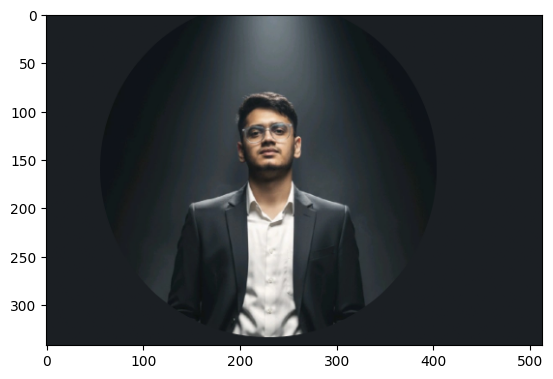

In [45]:
plt.imshow(img)

In [46]:
img_rescale= resize(img, (100,100))

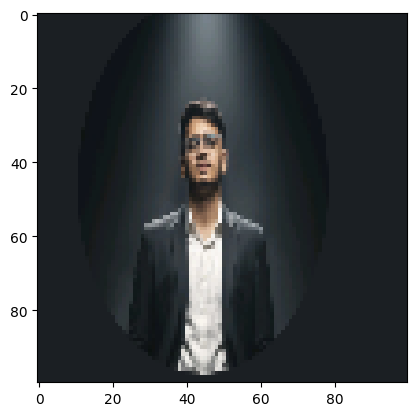

In [47]:
plt.imshow(img_rescale)


In [48]:
hr_flip = np.fliplr(img) #flip left to right

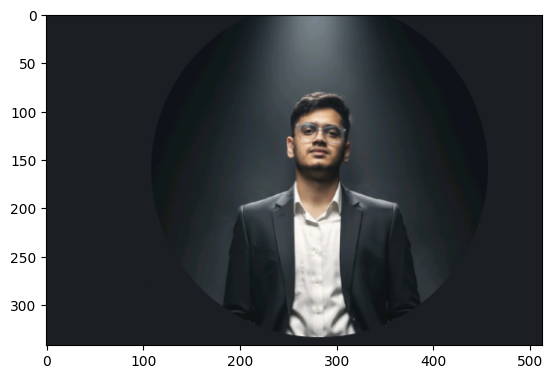

In [49]:
plt.imshow(hr_flip)

In [50]:
vertical_flip = np.flipud(img)

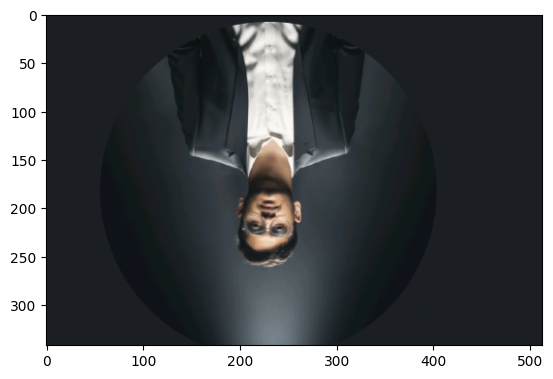

In [51]:
plt.imshow(vertical_flip)

#Rotation

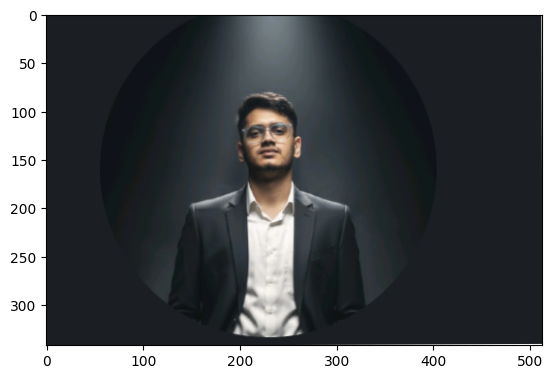

In [52]:
from skimage import transform
trans_img = transform.rotate(img, random.uniform(-40,40))
plt.imshow(trans_img)

In [53]:
#Adding Noise

In [54]:
from skimage.util import random_noise

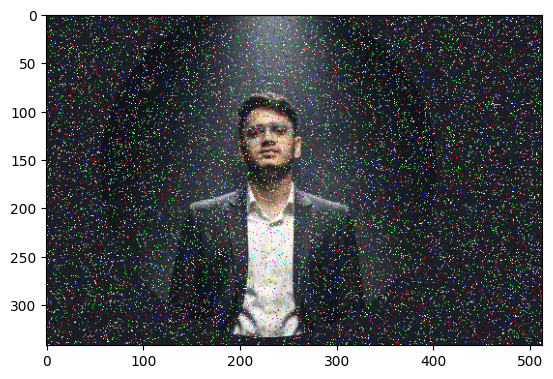

In [59]:
image_noise = random_noise(img , mode = 's&p', clip=True)
plt.imshow(image_noise)

In [58]:
mpimg.imsave('noisy_image.png', image_noise)